# Temporal Mamba Study Visualization

This notebook visualizes saved raw outputs from `temporal_mamba_sensitivity_ablation.ipynb`.

It is designed for interactive use:
- inspect the saved raw and summarized tables,
- render each sensitivity analysis figure individually,
- display ablation results in the same style as the study notebook,
- optionally save refreshed figures and summary tables.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'exp').exists():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / 'exp').exists(), 'Run this notebook from the repo root or notebooks/.'

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_rows', 200)


In [2]:
INPUT_DIR = REPO_ROOT / 'notebooks' / 'artifacts' / 'temporal-mamba-trade-studies'
OUTPUT_DIR = INPUT_DIR / 'visualizations_notebook'
DATASET_LABEL = 'tgbn-trade'
MODEL_LABEL = 'Temporal Mamba Sheaf'
METRIC_COLUMN = 'best_test_metric'
SAVE_ARTIFACTS = True

SENSITIVITY_RAW_PATH = INPUT_DIR / 'sensitivity_raw.csv'
ABLATION_RAW_PATH = INPUT_DIR / 'ablation_raw.csv'

print({
    'input_dir': str(INPUT_DIR),
    'output_dir': str(OUTPUT_DIR),
    'dataset_label': DATASET_LABEL,
    'model_label': MODEL_LABEL,
    'metric_column': METRIC_COLUMN,
    'save_artifacts': SAVE_ARTIFACTS,
})


{'input_dir': '/home/zhuowez1/project/neural-sheaf-diffusion/notebooks/artifacts/temporal-mamba-trade-studies', 'output_dir': '/home/zhuowez1/project/neural-sheaf-diffusion/notebooks/artifacts/temporal-mamba-trade-studies/visualizations_notebook', 'dataset_label': 'tgbn-trade', 'model_label': 'Temporal Mamba Sheaf', 'metric_column': 'best_test_metric', 'save_artifacts': True}


In [3]:
NUMERIC_COLUMNS = [
    'value',
    'repeat',
    'seed',
    'best_epoch',
    'best_train_metric',
    'best_val_metric',
    'best_test_metric',
    'best_train_loss',
    'best_val_loss',
    'best_test_loss',
    'search_best_test_metric',
    'search_best_val_loss',
    'time_window',
]

SUMMARY_METRICS = [
    'best_epoch',
    'best_train_metric',
    'best_val_metric',
    'best_test_metric',
    'best_train_loss',
    'best_val_loss',
    'best_test_loss',
    'search_best_test_metric',
    'search_best_val_loss',
]

PARAMETER_LABELS = {
    'time_window': 'Snapshot Time Window',
    'lr': 'Learning Rate',
    'weight_decay': 'Weight Decay',
    'hidden_channels': 'Hidden Channels',
    'layers': 'Diffusion Layers',
    'dropout': 'Dropout',
    'd': 'Stalk Width',
    'temporal_d_model': 'Temporal Hidden Size',
    'closure_hops': 'Closure Hops',
    'temporal_bptt_steps': 'BPTT Steps',
    'left_weights': 'Left Weights',
    'right_weights': 'Right Weights',
    'second_linear': 'Second Linear Layer',
    'edge_weights': 'Edge Weights',
}


def load_raw_results(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    for column in NUMERIC_COLUMNS:
        if column in df.columns:
            df[column] = pd.to_numeric(df[column], errors='coerce')
    return df


def summarize_runs(raw_df: pd.DataFrame) -> pd.DataFrame:
    group_cols = ['study', 'parameter', 'value', 'value_label', 'experiment_name']
    summary = raw_df.groupby(group_cols, dropna=False)[SUMMARY_METRICS].agg(['mean', 'std', 'count']).reset_index()
    summary.columns = [
        '_'.join(part for part in column if part).rstrip('_') if isinstance(column, tuple) else column
        for column in summary.columns
    ]
    return summary


def pretty_label(name: str) -> str:
    return PARAMETER_LABELS.get(name, name.replace('_', ' ').title())


def metric_axis_label(metric_column: str, metric_name: str) -> str:
    split = metric_column.replace('best_', '').replace('_metric', '').replace('_', ' ').title()
    return f'Mean {split} {metric_name.upper()}'


def round_tick_formatter(decimals: int = 3):
    return FuncFormatter(lambda value, pos: f'{value:.{decimals}f}')


def value_sort_key(parameter: str, value_label: str, numeric_value):
    if parameter in {'left_weights', 'right_weights', 'second_linear', 'edge_weights'}:
        order = {'False': 0, 'True': 1}
        return order.get(str(value_label), 99)
    if pd.notna(numeric_value):
        return float(numeric_value)
    return str(value_label)


def formatted_value_label(parameter: str, value_label: str, numeric_value):
    if parameter in {'lr', 'weight_decay'} and pd.notna(numeric_value):
        return f'{float(numeric_value):.2e}'
    if parameter in {'dropout'} and pd.notna(numeric_value):
        return f'{float(numeric_value):.2f}'
    if parameter == 'time_window':
        if pd.isna(numeric_value):
            return 'Exact'
        return str(int(numeric_value))
    if pd.notna(numeric_value) and float(numeric_value).is_integer():
        return str(int(numeric_value))
    return str(value_label)


def style_axis(ax, y_label: str):
    ax.set_ylabel(y_label)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.yaxis.set_major_formatter(round_tick_formatter(3))
    ax.grid(axis='y', alpha=0.25)
    ax.grid(axis='x', visible=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


def build_sensitivity_figure(summary_df, parameter, metric_column, metric_name, dataset_label, model_label):
    metric_mean_col = f'{metric_column}_mean'
    metric_std_col = f'{metric_column}_std'

    param_df = summary_df[summary_df['parameter'] == parameter].copy()
    if param_df.empty:
        return None, None

    param_df['sort_key'] = [
        value_sort_key(parameter, value_label, value)
        for value_label, value in zip(param_df['value_label'], param_df['value'])
    ]
    param_df = param_df.sort_values(by=['sort_key', 'value_label'], kind='stable').reset_index(drop=True)

    x = np.arange(len(param_df))
    y = param_df[metric_mean_col].to_numpy(dtype=float)
    yerr = param_df[metric_std_col].fillna(0.0).to_numpy(dtype=float)
    labels = [
        formatted_value_label(parameter, value_label, value)
        for value_label, value in zip(param_df['value_label'], param_df['value'])
    ]

    fig, ax = plt.subplots(figsize=(7.6, 4.8))
    ax.errorbar(
        x,
        y,
        yerr=yerr,
        fmt='o-',
        color='#1f5aa6',
        ecolor='#7aa6d8',
        elinewidth=1.4,
        linewidth=2.0,
        capsize=4,
        markersize=6,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=0)
    ax.set_xlabel(pretty_label(parameter))
    style_axis(ax, metric_axis_label(metric_column, metric_name))
    ax.set_title(f'Sensitivity to {pretty_label(parameter)}')
    fig.tight_layout()
    return fig, param_df


def build_ablation_bar_figure(summary_df, metric_column, metric_name, dataset_label, model_label):
    metric_mean_col = f'{metric_column}_mean'
    metric_std_col = f'{metric_column}_std'
    ablation_df = summary_df.copy()
    if ablation_df.empty:
        return None

    flags = list(dict.fromkeys(ablation_df['parameter'].tolist()))
    x = np.arange(len(flags))
    width = 0.34

    false_means, false_stds, true_means, true_stds = [], [], [], []
    for flag in flags:
        flag_df = ablation_df[ablation_df['parameter'] == flag].set_index('value_label')
        false_means.append(flag_df.loc['False', metric_mean_col] if 'False' in flag_df.index else np.nan)
        false_stds.append(flag_df.loc['False', metric_std_col] if 'False' in flag_df.index else 0.0)
        true_means.append(flag_df.loc['True', metric_mean_col] if 'True' in flag_df.index else np.nan)
        true_stds.append(flag_df.loc['True', metric_std_col] if 'True' in flag_df.index else 0.0)

    fig, ax = plt.subplots(figsize=(8.8, 4.8))
    ax.bar(
        x - width / 2,
        false_means,
        width,
        yerr=false_stds,
        color='#cfd8dc',
        edgecolor='#78909c',
        capsize=4,
        label='Disabled',
    )
    ax.bar(
        x + width / 2,
        true_means,
        width,
        yerr=true_stds,
        color='#2e7d32',
        edgecolor='#1b5e20',
        capsize=4,
        label='Enabled',
    )
    ax.set_xticks(x)
    ax.set_xticklabels([pretty_label(flag) for flag in flags], rotation=0)
    style_axis(ax, metric_axis_label(metric_column, metric_name))
    ax.set_title('Ablation Study')
    ax.legend(frameon=False, ncol=2, loc='lower right')
    fig.tight_layout()
    return fig


def build_ablation_pivot(summary_df, metric_column):
    metric_mean_col = f'{metric_column}_mean'
    metric_std_col = f'{metric_column}_std'

    pivot_mean = summary_df.pivot(index='parameter', columns='value_label', values=metric_mean_col)
    pivot_std = summary_df.pivot(index='parameter', columns='value_label', values=metric_std_col)
    pivot_mean.columns = [str(column) for column in pivot_mean.columns]
    pivot_std.columns = [str(column) for column in pivot_std.columns]
    ordered_columns = [column for column in ['False', 'True'] if column in pivot_mean.columns]
    if not ordered_columns:
        ordered_columns = list(pivot_mean.columns)
    pivot_mean = pivot_mean.reindex(columns=ordered_columns)
    pivot_std = pivot_std.reindex(columns=ordered_columns)
    pivot_mean.index = [pretty_label(index) for index in pivot_mean.index]
    pivot_std.index = [pretty_label(index) for index in pivot_std.index]

    display_df = pivot_mean.copy()
    for column in display_df.columns:
        display_df[column] = [
            f'{mean:.4f} +/- {std:.4f}' if pd.notna(mean) else ''
            for mean, std in zip(pivot_mean[column], pivot_std[column].fillna(0.0))
        ]
    return pivot_mean, pivot_std, display_df


def ensure_output_dir(path: Path):
    path.mkdir(parents=True, exist_ok=True)
    return path


In [4]:
assert SENSITIVITY_RAW_PATH.exists() or ABLATION_RAW_PATH.exists(), (
    f'Could not find sensitivity_raw.csv or ablation_raw.csv under {INPUT_DIR}'
)

sensitivity_raw_df = load_raw_results(SENSITIVITY_RAW_PATH) if SENSITIVITY_RAW_PATH.exists() else None
ablation_raw_df = load_raw_results(ABLATION_RAW_PATH) if ABLATION_RAW_PATH.exists() else None

sensitivity_summary_df = summarize_runs(sensitivity_raw_df) if sensitivity_raw_df is not None else None
ablation_summary_df = summarize_runs(ablation_raw_df) if ablation_raw_df is not None else None

sensitivity_metric_name = (
    sensitivity_raw_df['metric_name'].dropna().iloc[0] if sensitivity_raw_df is not None and 'metric_name' in sensitivity_raw_df else 'metric'
)
ablation_metric_name = (
    ablation_raw_df['metric_name'].dropna().iloc[0] if ablation_raw_df is not None and 'metric_name' in ablation_raw_df else 'metric'
)

display(Markdown('**Loaded artifact files**'))
display(pd.DataFrame([
    {'artifact': 'sensitivity_raw', 'path': str(SENSITIVITY_RAW_PATH), 'exists': SENSITIVITY_RAW_PATH.exists()},
    {'artifact': 'ablation_raw', 'path': str(ABLATION_RAW_PATH), 'exists': ABLATION_RAW_PATH.exists()},
]))

print({
    'sensitivity_rows': 0 if sensitivity_raw_df is None else len(sensitivity_raw_df),
    'ablation_rows': 0 if ablation_raw_df is None else len(ablation_raw_df),
    'sensitivity_metric_name': sensitivity_metric_name,
    'ablation_metric_name': ablation_metric_name,
})


**Loaded artifact files**

,artifact,path,exists
0,sensitivity_raw,/home/zhuowez1/project/neural-sheaf-diffusion/notebooks/artifacts/temporal-mamba-trade-studies/sensitivity_raw.csv,True
1,ablation_raw,/home/zhuowez1/project/neural-sheaf-diffusion/notebooks/artifacts/temporal-mamba-trade-studies/ablation_raw.csv,True


{'sensitivity_rows': 150, 'ablation_rows': 40, 'sensitivity_metric_name': 'ndcg', 'ablation_metric_name': 'ndcg'}


## Sensitivity Summary

In [5]:
if sensitivity_summary_df is not None:
    sensitivity_display_cols = [
        'parameter',
        'value_label',
        'best_val_metric_mean',
        'best_val_metric_std',
        'best_test_metric_mean',
        'best_test_metric_std',
        'best_epoch_mean',
        'best_epoch_std',
    ]
    display(
        sensitivity_summary_df[sensitivity_display_cols]
        .assign(parameter=lambda df: df['parameter'].map(pretty_label))
    )
else:
    print('No sensitivity study results found.')


,parameter,value_label,best_val_metric_mean,best_val_metric_std,best_test_metric_mean,best_test_metric_std,best_epoch_mean,best_epoch_std
0,Closure Hops,1.000000e+00,0.997688,0.000652,0.997688,0.000652,136.4,17.854971
1,Closure Hops,2.000000e+00,0.997613,0.001545,0.997613,0.001545,130.8,19.929877
2,Closure Hops,3.000000e+00,0.997801,0.000862,0.997801,0.000862,148.4,6.841053
3,Stalk Width,2.000000e+00,0.997400,0.001388,0.997400,0.001388,167.2,26.023067
4,Stalk Width,4.000000e+00,0.997728,0.000444,0.997728,0.000444,122.0,31.144823
5,Stalk Width,6.000000e+00,0.997309,0.001093,0.997309,0.001093,134.4,31.855926
6,Dropout,0.000000e+00,0.997541,0.000760,0.997541,0.000760,129.6,31.157664
7,Dropout,5.000000e-02,0.988764,0.001787,0.988764,0.001787,127.2,17.753873
8,Dropout,1.000000e-01,0.988394,0.001405,0.988394,0.001405,174.4,28.892906
9,Hidden Channels,3.200000e+01,0.996500,0.001730,0.996500,0.001730,140.0,22.271057


## Sensitivity Figures

This cell renders each parameter sweep as its own figure for easier inspection.

### Closure Hops

,value_label,best_test_metric_mean,best_test_metric_std,best_epoch_mean,best_epoch_std
0,1.0,0.997688,0.000652,136.4,17.854971
1,2.0,0.997613,0.001545,130.8,19.929877
2,3.0,0.997801,0.000862,148.4,6.841053


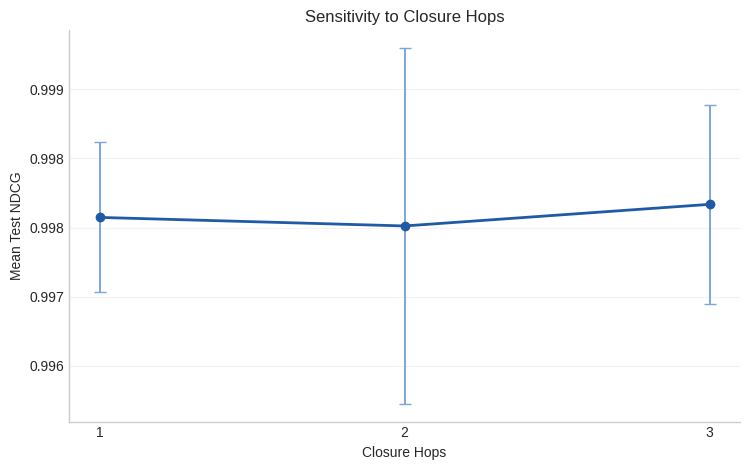

### Stalk Width

,value_label,best_test_metric_mean,best_test_metric_std,best_epoch_mean,best_epoch_std
0,2.0,0.997400,0.001388,167.2,26.023067
1,4.0,0.997728,0.000444,122.0,31.144823
2,6.0,0.997309,0.001093,134.4,31.855926


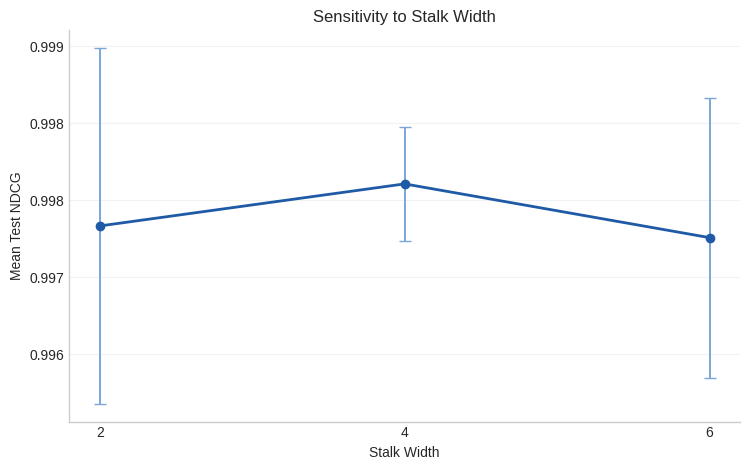

### Dropout

,value_label,best_test_metric_mean,best_test_metric_std,best_epoch_mean,best_epoch_std
0,0.00,0.997541,0.000760,129.6,31.157664
1,0.05,0.988764,0.001787,127.2,17.753873
2,0.10,0.988394,0.001405,174.4,28.892906


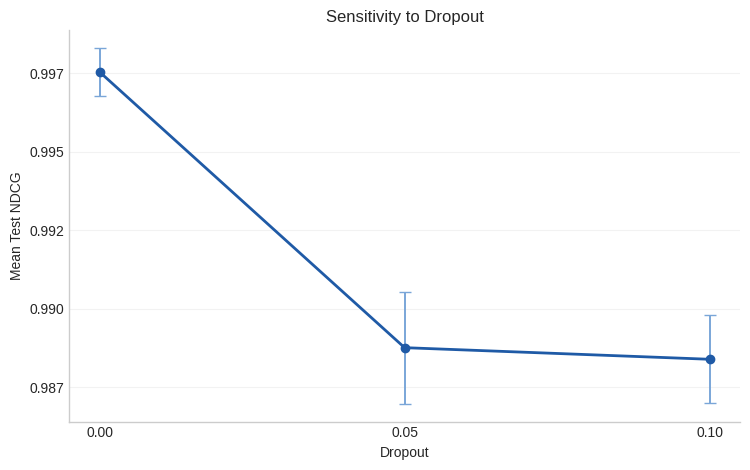

### Hidden Channels

,value_label,best_test_metric_mean,best_test_metric_std,best_epoch_mean,best_epoch_std
0,32.0,0.996500,0.001730,140.0,22.271057
1,64.0,0.998180,0.000261,140.0,28.319605
2,96.0,0.996473,0.002077,147.6,34.246168


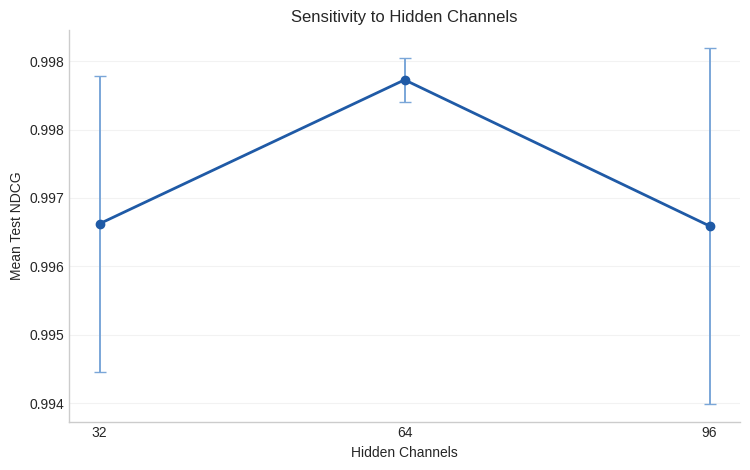

### Diffusion Layers

,value_label,best_test_metric_mean,best_test_metric_std,best_epoch_mean,best_epoch_std
0,2.0,0.997285,0.000669,132.0,23.108440
1,3.0,0.995568,0.004555,107.6,15.517732
2,4.0,0.997320,0.001494,145.2,36.676968


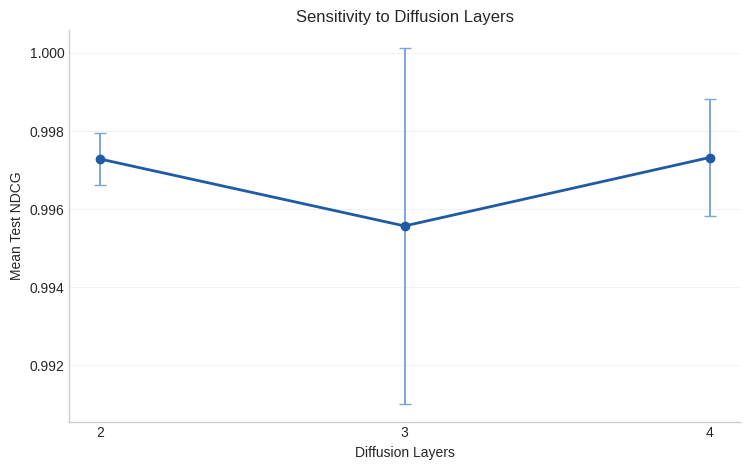

### Learning Rate

,value_label,best_test_metric_mean,best_test_metric_std,best_epoch_mean,best_epoch_std
0,0.006244,0.999023,0.000375,158.0,24.535688
1,0.012488,0.997625,0.001022,124.4,22.199099
2,0.018732,0.993907,0.003646,155.6,28.121166


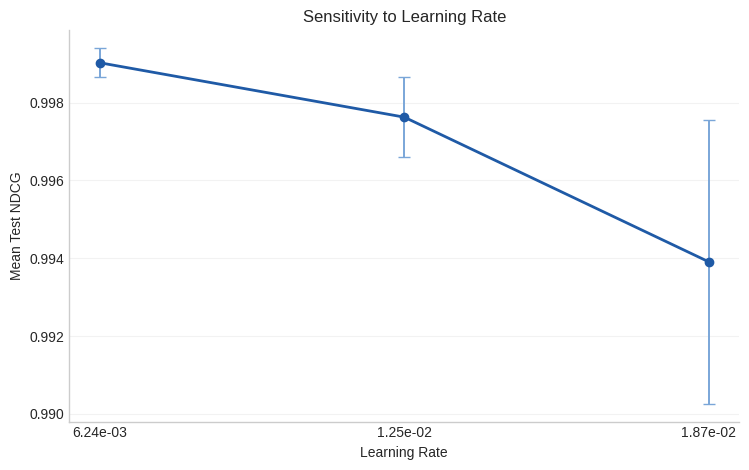

### BPTT Steps

,value_label,best_test_metric_mean,best_test_metric_std,best_epoch_mean,best_epoch_std
0,4.0,0.996899,0.001815,118.4,14.993332
1,8.0,0.997292,0.001051,122.8,30.938649
2,16.0,0.997784,0.000367,133.6,31.540450


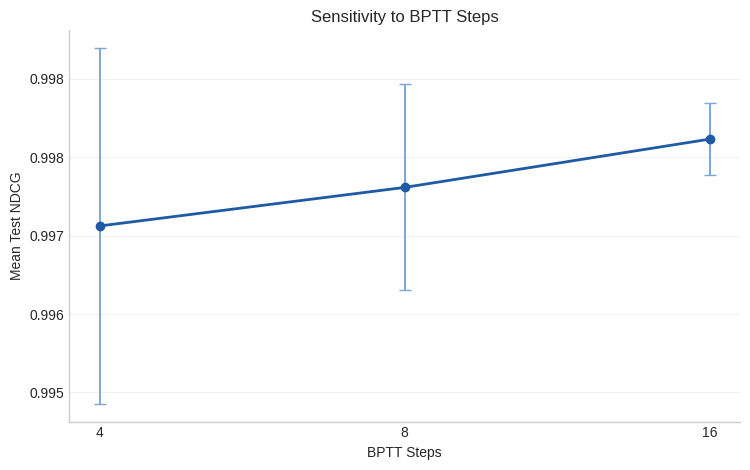

### Temporal Hidden Size

,value_label,best_test_metric_mean,best_test_metric_std,best_epoch_mean,best_epoch_std
0,16.0,0.996183,0.001267,144.4,12.680694
1,32.0,0.997828,0.001142,141.2,27.224989
2,64.0,0.994157,0.003459,117.6,32.784143


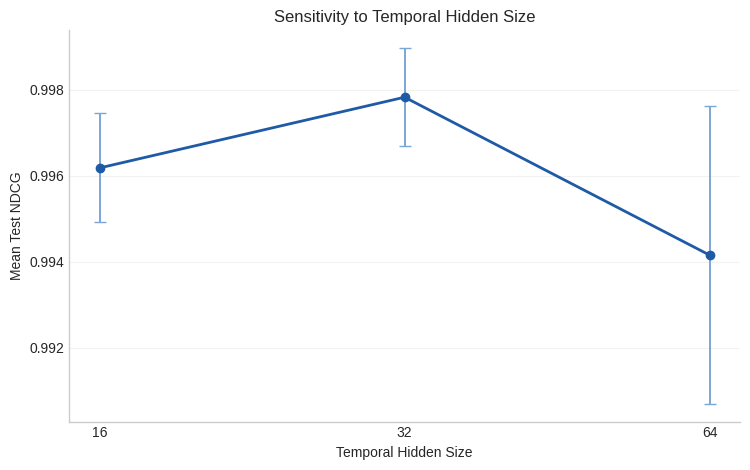

### Snapshot Time Window

,value_label,best_test_metric_mean,best_test_metric_std,best_epoch_mean,best_epoch_std
0,1.0,0.784863,0.134966,143.6,61.390553
1,3.0,0.997517,0.001499,129.6,18.022209
2,5.0,0.998049,0.000529,137.2,20.029978


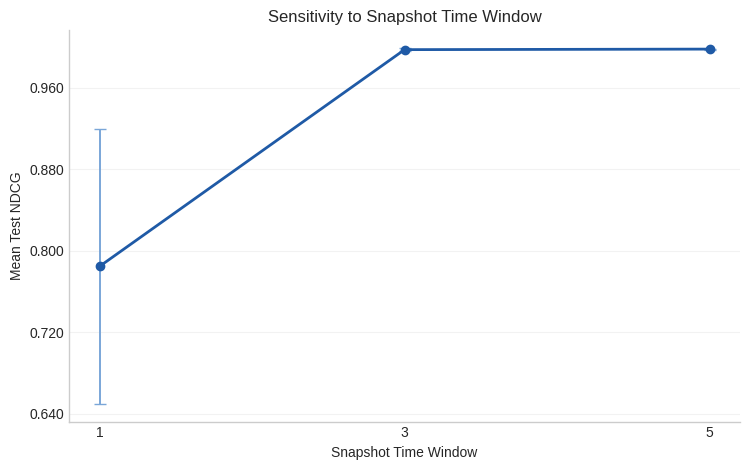

### Weight Decay

,value_label,best_test_metric_mean,best_test_metric_std,best_epoch_mean,best_epoch_std
0,1.984176e-08,0.997422,0.001691,128.4,13.885244
1,1.984176e-07,0.997025,0.001372,121.2,34.017642
2,1.984176e-06,0.997224,0.001385,122.8,27.878307


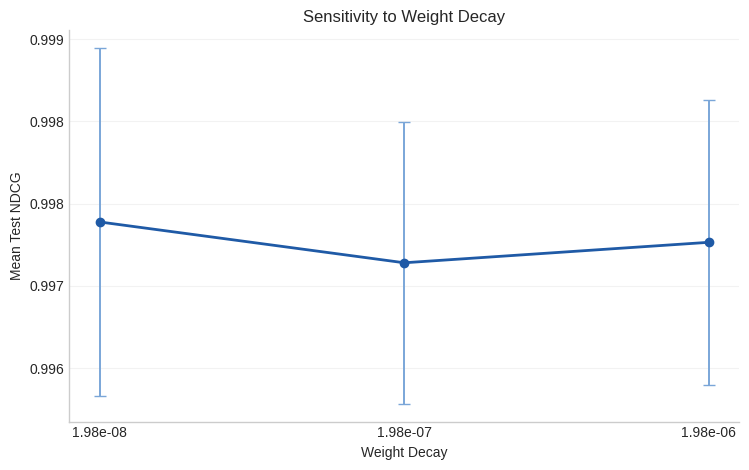

[PosixPath('/home/zhuowez1/project/neural-sheaf-diffusion/notebooks/artifacts/temporal-mamba-trade-studies/visualizations_notebook/sensitivity/closure_hops.png'),
 PosixPath('/home/zhuowez1/project/neural-sheaf-diffusion/notebooks/artifacts/temporal-mamba-trade-studies/visualizations_notebook/sensitivity/d.png'),
 PosixPath('/home/zhuowez1/project/neural-sheaf-diffusion/notebooks/artifacts/temporal-mamba-trade-studies/visualizations_notebook/sensitivity/dropout.png'),
 PosixPath('/home/zhuowez1/project/neural-sheaf-diffusion/notebooks/artifacts/temporal-mamba-trade-studies/visualizations_notebook/sensitivity/hidden_channels.png'),
 PosixPath('/home/zhuowez1/project/neural-sheaf-diffusion/notebooks/artifacts/temporal-mamba-trade-studies/visualizations_notebook/sensitivity/layers.png'),
 PosixPath('/home/zhuowez1/project/neural-sheaf-diffusion/notebooks/artifacts/temporal-mamba-trade-studies/visualizations_notebook/sensitivity/lr.png'),
 PosixPath('/home/zhuowez1/project/neural-sheaf-dif

In [6]:
generated_sensitivity_paths = []

if sensitivity_summary_df is not None:
    sensitivity_output_dir = ensure_output_dir(OUTPUT_DIR / 'sensitivity')
    ordered_parameters = sensitivity_summary_df['parameter'].drop_duplicates().tolist()

    for parameter in ordered_parameters:
        display(Markdown(f'### {pretty_label(parameter)}'))
        fig, plot_df = build_sensitivity_figure(
            sensitivity_summary_df,
            parameter=parameter,
            metric_column=METRIC_COLUMN,
            metric_name=sensitivity_metric_name,
            dataset_label=DATASET_LABEL,
            model_label=MODEL_LABEL,
        )
        if fig is None:
            continue
        display(plot_df[[
            'value_label',
            f'{METRIC_COLUMN}_mean',
            f'{METRIC_COLUMN}_std',
            'best_epoch_mean',
            'best_epoch_std',
        ]])
        plt.show()
        if SAVE_ARTIFACTS:
            output_path = sensitivity_output_dir / f'{parameter}.png'
            fig.savefig(output_path, dpi=220, bbox_inches='tight')
            generated_sensitivity_paths.append(output_path)
        plt.close(fig)

    if SAVE_ARTIFACTS:
        sensitivity_summary_save = sensitivity_output_dir / 'sensitivity_summary.csv'
        sensitivity_summary_df.assign(parameter=lambda df: df['parameter'].map(pretty_label)).to_csv(sensitivity_summary_save, index=False)
        generated_sensitivity_paths.append(sensitivity_summary_save)

generated_sensitivity_paths


## Combined Sensitivity Figure

This cell assembles a single six-panel figure in the requested order for paper use.

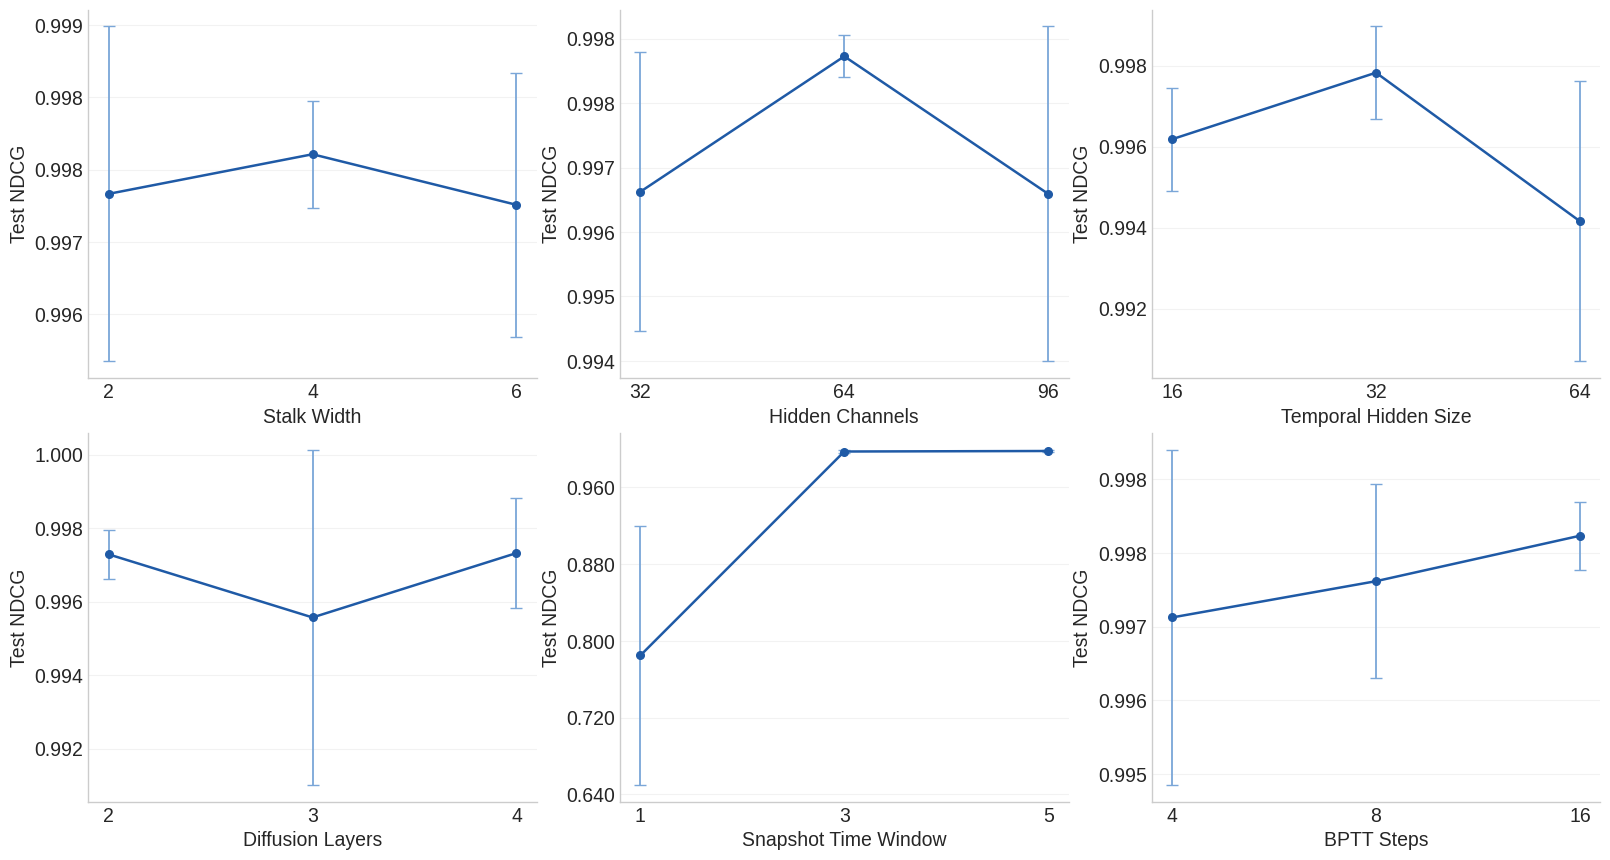

PosixPath('/home/zhuowez1/project/neural-sheaf-diffusion/notebooks/artifacts/temporal-mamba-trade-studies/visualizations_notebook/sensitivity/sensitivity_analysis_combined.png')

In [ ]:
combined_sensitivity_path = None

if sensitivity_summary_df is not None:
    combined_order = [
        'd',
        'hidden_channels',
        'temporal_d_model',
        'layers',
        'time_window',
        'temporal_bptt_steps',
    ]
    available_parameters = set(sensitivity_summary_df['parameter'])
    plot_parameters = [parameter for parameter in combined_order if parameter in available_parameters]

    fig, axes = plt.subplots(2, 3, figsize=(16, 8.5), squeeze=False)
    flat_axes = axes.flatten()
    metric_mean_col = f'{METRIC_COLUMN}_mean'
    metric_std_col = f'{METRIC_COLUMN}_std'
    font_delta = 10

    for ax, parameter in zip(flat_axes, plot_parameters):
        param_df = sensitivity_summary_df[sensitivity_summary_df['parameter'] == parameter].copy()
        param_df['sort_key'] = [
            value_sort_key(parameter, value_label, value)
            for value_label, value in zip(param_df['value_label'], param_df['value'])
        ]
        param_df = param_df.sort_values(by=['sort_key', 'value_label'], kind='stable').reset_index(drop=True)

        x = np.arange(len(param_df))
        y = param_df[metric_mean_col].to_numpy(dtype=float)
        yerr = param_df[metric_std_col].fillna(0.0).to_numpy(dtype=float)
        labels = [
            formatted_value_label(parameter, value_label, value)
            for value_label, value in zip(param_df['value_label'], param_df['value'])
        ]

        ax.errorbar(
            x,
            y,
            yerr=yerr,
            fmt='o-',
            color='#1f5aa6',
            ecolor='#7aa6d8',
            elinewidth=1.3,
            linewidth=1.8,
            capsize=4,
            markersize=5.5,
        )
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=0, fontsize=10 + font_delta)
        ax.set_xlabel(pretty_label(parameter), fontsize=10 + font_delta)
        style_axis(ax, 'Test NDCG')
        ax.yaxis.label.set_size(10 + font_delta)
        ax.tick_params(axis='y', labelsize=10 + font_delta)

    for ax in flat_axes[len(plot_parameters):]:
        ax.axis('off')

    fig.tight_layout(pad=0.35, w_pad=0.35, h_pad=0.5)
    plt.show()

    if SAVE_ARTIFACTS:
        combined_output_dir = ensure_output_dir(OUTPUT_DIR / 'sensitivity')
        combined_sensitivity_path = combined_output_dir / 'sensitivity_analysis_combined.png'
        fig.savefig(combined_sensitivity_path, dpi=220, bbox_inches='tight')
    plt.close(fig)

combined_sensitivity_path


## Ablation Results

,parameter,value_label,best_val_metric_mean,best_val_metric_std,best_test_metric_mean,best_test_metric_std,best_epoch_mean
0,Edge Weights,False,0.997814,0.000877,0.997814,0.000877,136.4
1,Edge Weights,True,0.995235,0.001128,0.995235,0.001128,165.6
2,Left Weights,False,0.996983,0.002800,0.996983,0.002800,142.8
3,Left Weights,True,0.997167,0.000659,0.997167,0.000659,119.6
4,Right Weights,False,0.972998,0.030956,0.972998,0.030956,196.4
5,Right Weights,True,0.997844,0.000746,0.997844,0.000746,134.4
6,Second Linear Layer,False,0.998043,0.000300,0.998043,0.000300,145.2
7,Second Linear Layer,True,0.996412,0.000940,0.996412,0.000940,134.0


**Ablation mean test metric by flag value**

,False,True
Edge Weights,0.9978 +/- 0.0009,0.9952 +/- 0.0011
Left Weights,0.9970 +/- 0.0028,0.9972 +/- 0.0007
Right Weights,0.9730 +/- 0.0310,0.9978 +/- 0.0007
Second Linear Layer,0.9980 +/- 0.0003,0.9964 +/- 0.0009


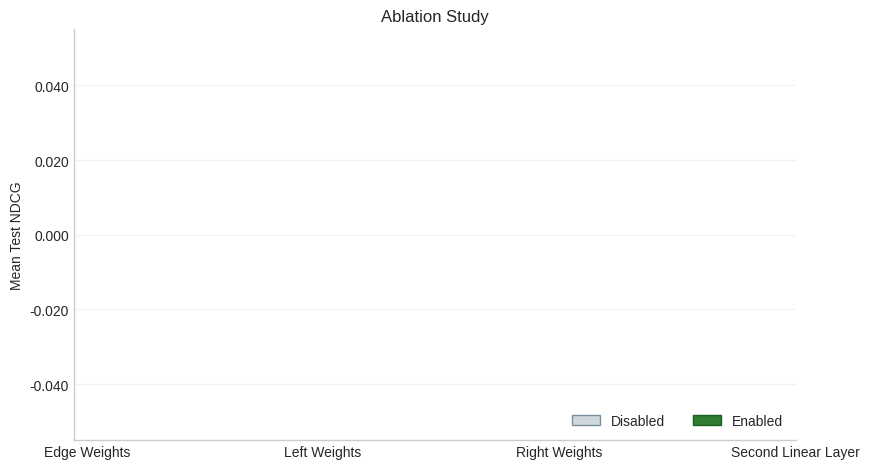

[PosixPath('/home/zhuowez1/project/neural-sheaf-diffusion/notebooks/artifacts/temporal-mamba-trade-studies/visualizations_notebook/ablation/ablation_bar_plot.png'),
 PosixPath('/home/zhuowez1/project/neural-sheaf-diffusion/notebooks/artifacts/temporal-mamba-trade-studies/visualizations_notebook/ablation/ablation_summary.csv'),
 PosixPath('/home/zhuowez1/project/neural-sheaf-diffusion/notebooks/artifacts/temporal-mamba-trade-studies/visualizations_notebook/ablation/ablation_pivot.csv')]

In [8]:
generated_ablation_paths = []

if ablation_summary_df is not None:
    ablation_display_cols = [
        'parameter',
        'value_label',
        'best_val_metric_mean',
        'best_val_metric_std',
        'best_test_metric_mean',
        'best_test_metric_std',
        'best_epoch_mean',
    ]
    display(
        ablation_summary_df[ablation_display_cols]
        .assign(parameter=lambda df: df['parameter'].map(pretty_label))
    )

    pivot_mean_df, pivot_std_df, pivot_display_df = build_ablation_pivot(ablation_summary_df, METRIC_COLUMN)
    display(Markdown('**Ablation mean test metric by flag value**'))
    display(pivot_display_df)

    ablation_fig = build_ablation_bar_figure(
        ablation_summary_df,
        metric_column=METRIC_COLUMN,
        metric_name=ablation_metric_name,
        dataset_label=DATASET_LABEL,
        model_label=MODEL_LABEL,
    )
    if ablation_fig is not None:
        plt.show()
        if SAVE_ARTIFACTS:
            ablation_output_dir = ensure_output_dir(OUTPUT_DIR / 'ablation')
            ablation_plot_path = ablation_output_dir / 'ablation_bar_plot.png'
            ablation_fig.savefig(ablation_plot_path, dpi=220, bbox_inches='tight')
            generated_ablation_paths.append(ablation_plot_path)
        plt.close(ablation_fig)

    if SAVE_ARTIFACTS:
        ablation_output_dir = ensure_output_dir(OUTPUT_DIR / 'ablation')
        ablation_summary_save = ablation_output_dir / 'ablation_summary.csv'
        ablation_pivot_save = ablation_output_dir / 'ablation_pivot.csv'
        ablation_summary_df.assign(parameter=lambda df: df['parameter'].map(pretty_label)).to_csv(ablation_summary_save, index=False)
        pivot_mean_df.to_csv(ablation_pivot_save)
        generated_ablation_paths.extend([ablation_summary_save, ablation_pivot_save])

generated_ablation_paths


## Saved Artifacts

In [9]:
all_generated_paths = generated_sensitivity_paths + generated_ablation_paths
display(pd.DataFrame({'generated_path': [str(path) for path in all_generated_paths]}))


,generated_path
0,/home/zhuowez1/project/neural-sheaf-diffusion/notebooks/artifacts/temporal-mamba-trade-studies/visualizations_notebo...
1,/home/zhuowez1/project/neural-sheaf-diffusion/notebooks/artifacts/temporal-mamba-trade-studies/visualizations_notebo...
2,/home/zhuowez1/project/neural-sheaf-diffusion/notebooks/artifacts/temporal-mamba-trade-studies/visualizations_notebo...
3,/home/zhuowez1/project/neural-sheaf-diffusion/notebooks/artifacts/temporal-mamba-trade-studies/visualizations_notebo...
4,/home/zhuowez1/project/neural-sheaf-diffusion/notebooks/artifacts/temporal-mamba-trade-studies/visualizations_notebo...
5,/home/zhuowez1/project/neural-sheaf-diffusion/notebooks/artifacts/temporal-mamba-trade-studies/visualizations_notebo...
6,/home/zhuowez1/project/neural-sheaf-diffusion/notebooks/artifacts/temporal-mamba-trade-studies/visualizations_notebo...
7,/home/zhuowez1/project/neural-sheaf-diffusion/notebooks/artifacts/temporal-mamba-trade-studies/visualizations_notebo...
8,/home/zhuowez1/project/neural-sheaf-diffusion/notebooks/artifacts/temporal-mamba-trade-studies/visualizations_notebo...
9,/home/zhuowez1/project/neural-sheaf-diffusion/notebooks/artifacts/temporal-mamba-trade-studies/visualizations_notebo...
